## Dataset download

In [11]:
import pandas as pd

df = pd.read_csv("databases/nba_dataset_2010_2025.csv")
drop_cols = ["Player", "Team", "Pos", "season"]

df.drop(columns=drop_cols, inplace=True)

In [2]:
df

,Age,G,GS,MP_avg,FG,FGA,FG%,3P,3PA,3P%,...,Offense Four Factors FT/FGA,Defense Four Factors eFG%,Defense Four Factors TOV%,Defense Four Factors DRB%,Defense Four Factors FT/FGA,potw_count,potm_count,rookie_of_month_count,is_rookie,target
0,23.0,56.0,2.0,15.4,2.6,6.3,0.410,1.1,3.1,0.345,...,0.229000,0.4900,13.400000,73.00,0.2580,0,0,0,1,0
1,25.0,82.0,82.0,35.6,7.0,16.2,0.432,2.5,6.4,0.398,...,0.225000,0.5110,13.600000,73.80,0.2150,0,0,0,0,0
2,25.0,32.0,0.0,9.7,1.3,2.6,0.512,0.0,0.0,0.000,...,0.203000,0.5035,12.900000,74.30,0.2085,0,0,0,0,0
3,25.0,26.0,1.0,9.0,1.3,2.9,0.467,0.2,0.6,0.313,...,0.235667,0.5000,14.033333,72.50,0.2220,0,0,0,0,0
4,25.0,31.0,0.0,7.8,1.0,2.7,0.376,0.2,0.7,0.238,...,0.221000,0.4840,13.200000,74.40,0.1950,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8196,29.0,74.0,74.0,35.2,8.4,16.5,0.511,3.2,7.2,0.446,...,0.181500,0.5480,11.650000,76.75,0.1890,0,0,0,0,0
8197,24.0,57.0,4.0,10.7,1.2,2.5,0.496,0.3,0.9,0.327,...,0.200000,0.5420,11.300000,74.60,0.1730,0,0,0,0,0
8198,23.0,63.0,45.0,24.5,3.4,8.3,0.412,1.6,4.8,0.341,...,0.189000,0.5570,13.700000,75.00,0.2180,0,0,0,0,0
8199,24.0,30.0,30.0,28.6,9.6,16.9,0.567,0.1,0.4,0.231,...,0.184000,0.5640,12.300000,72.70,0.1900,0,0,1,0,0


## Correlation

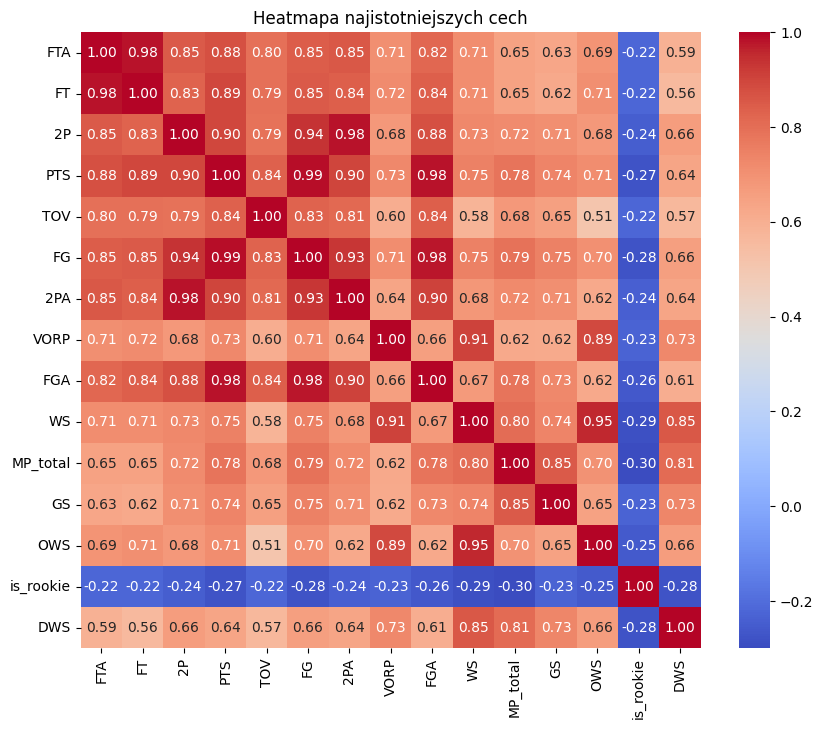

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# Oblicz korelację ze zmienną target
correlation_matrix = df.corr()
target_corr = correlation_matrix["target"].drop("target")  # usuń self-korelację

# Wybierz np. 10 zmiennych najbardziej skorelowanych z targetem
top_features = target_corr.abs().sort_values(ascending=False).head(15).index

# Podzbiór korelacji
reduced_corr = correlation_matrix.loc[top_features, top_features]

# Wizualizacja
plt.figure(figsize=(10, 8))
sns.heatmap(reduced_corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Heatmapa najistotniejszych cech")
plt.show()


| Grupa                           | Scalane do     |
| ------------------------------- | --------------------- |
| `2P`, `2PA`, `FG`, `FGA`, `PTS` | `FG` (albo `PTS`)     |
| `FTA`, `FT`                     | `FTA`                 |
| `WS`, `OWS`, `VORP`             | `VORP`                |
| `MP_total`, `GS`                | `MP_total`            |
| `TOV`, `DWS`, `is_rookie`       | zostają jako unikalne |


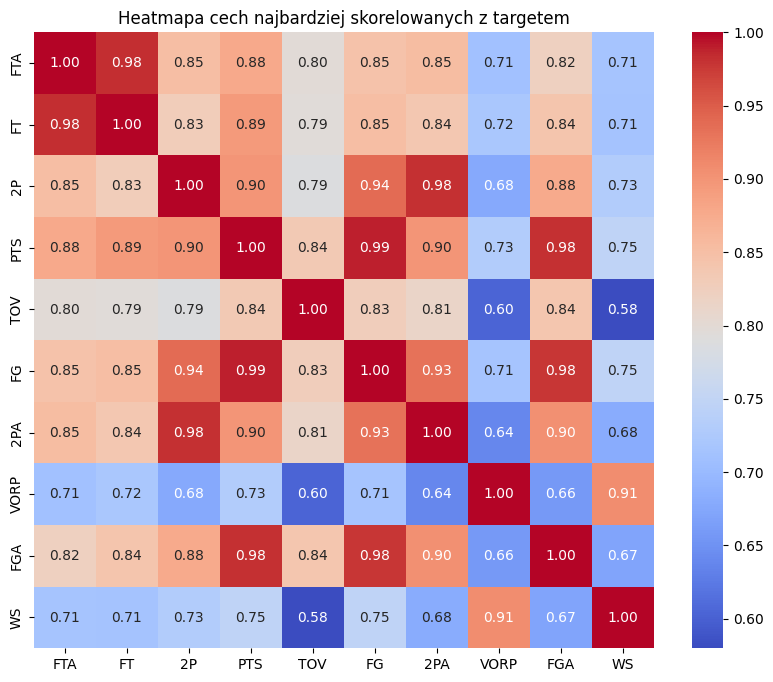

In [5]:
# 1. Korelacja na pełnym df (z targetem)
correlation_matrix = df.corr()

# 2. Korelacja cech z targetem
target_corr = correlation_matrix["target"].drop("target")

# 3. Wybierz 10 najbardziej skorelowanych cech
top_features = target_corr.abs().sort_values(ascending=False).head(10).index

# 4. Stwórz podzbiór z tymi cechami oraz targetem
selected_features = df[top_features.tolist() + ["target"]]

# 5. Oblicz korelację tylko wśród wybranych
reduced_corr = selected_features.corr()

# 6. Rysuj mapę korelacji (możesz wyciąć 'target' jeśli nie chcesz go pokazać)
plt.figure(figsize=(10, 8))
sns.heatmap(reduced_corr.drop("target", axis=0).drop("target", axis=1), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Heatmapa cech najbardziej skorelowanych z targetem")
plt.show()


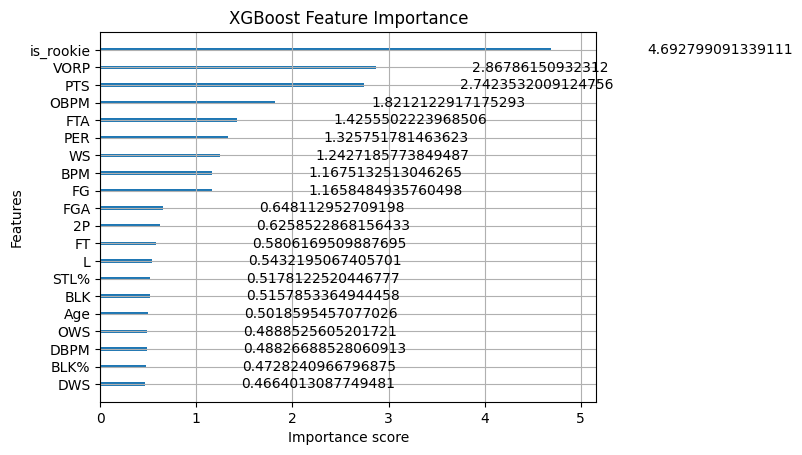

In [6]:
df.columns

Index(['Age', 'G', 'GS', 'MP_avg', 'FG', 'FGA', 'FG%', '3P', '3PA', '3P%',
       '2P', '2PA', '2P%', 'eFG%', 'FT', 'FTA', 'FT%', 'ORB', 'DRB', 'TRB',
       'AST', 'STL', 'BLK', 'TOV', 'PF', 'PTS', 'MP_total', 'PER', 'TS%',
       '3PAr', 'FTr', 'ORB%', 'DRB%', 'TRB%', 'AST%', 'STL%', 'BLK%', 'TOV%',
       'USG%', 'OWS', 'DWS', 'WS', 'WS/48', 'OBPM', 'DBPM', 'BPM', 'VORP', 'W',
       'L', 'MOV', 'SOS', 'SRS', 'ORtg', 'DRtg', 'NRtg', 'Pace',
       'Offense Four Factors eFG%', 'Offense Four Factors TOV%',
       'Offense Four Factors ORB%', 'Offense Four Factors FT/FGA',
       'Defense Four Factors eFG%', 'Defense Four Factors TOV%',
       'Defense Four Factors DRB%', 'Defense Four Factors FT/FGA',
       'potw_count', 'potm_count', 'rookie_of_month_count', 'is_rookie',
       'target'],
      dtype='object')

In [7]:
print(len(df.columns))

69


In [8]:
# Oblicz korelację wszystkich cech z targetem
correlation_matrix = df.corr(numeric_only=True)
target_corr = correlation_matrix["target"].drop("target")

# Posortuj od największej do najmniejszej korelacji
sorted_corr = target_corr.sort_values(ascending=False)

# Wyświetl wszystkie cechy i ich korelację z targetem
print("Korelacja cech z targetem (od najwyższej do najniższej):")
for feature, corr_value in sorted_corr.items():
    print(f"{feature:40s} →  {corr_value:.3f}")



Korelacja cech z targetem (od najwyższej do najniższej):
FTA                                      →  0.275
FT                                       →  0.267
2P                                       →  0.263
PTS                                      →  0.262
TOV                                      →  0.261
FG                                       →  0.260
2PA                                      →  0.260
VORP                                     →  0.251
FGA                                      →  0.249
WS                                       →  0.249
MP_total                                 →  0.242
GS                                       →  0.238
OWS                                      →  0.231
is_rookie                                →  0.227
DWS                                      →  0.224
MP_avg                                   →  0.219
DRB                                      →  0.215
TRB                                      →  0.205
AST                                      → 

## PCA

### Combining features ['2P', '2PA', 'FG', 'FGA', 'PTS']

In [5]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Wybrane cechy do PCA
pca_features = ['2P', '2PA', 'FG', 'FGA', 'PTS']

# Standaryzacja
X_pca = df[pca_features].dropna()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_pca)

# PCA – zachowaj wszystkie komponenty (dla analizy wariancji)
pca = PCA()
X_pca_transformed = pca.fit_transform(X_scaled)

# Udział wariancji
explained_variance = pca.explained_variance_ratio_
components_df = pd.DataFrame(pca.components_, columns=pca_features, index=[f'PC{i+1}' for i in range(len(pca_features))])
variance_df = pd.DataFrame({
    "Składowa": [f'PC{i+1}' for i in range(len(explained_variance))],
    "Wariancja [%]": explained_variance * 100
})
# Wyświetl wyniki
print("Wariancja wyjaśniona przez każdą składową PCA:")
print(variance_df)
print("\nSkładniki PCA:")
print(components_df)


Wariancja wyjaśniona przez każdą składową PCA:
  Składowa  Wariancja [%]
0      PC1      95.033874
1      PC2       4.063333
2      PC3       0.725327
3      PC4       0.146261
4      PC5       0.031205

Składniki PCA:
           2P       2PA        FG       FGA       PTS
PC1  0.441672  0.443794  0.455289  0.446179  0.449008
PC2  0.571707  0.508100 -0.199421 -0.454048 -0.411166
PC3 -0.405186  0.544639 -0.355983  0.552362 -0.327667
PC4 -0.195033  0.307808 -0.489153 -0.336122  0.717613
PC5 -0.525227  0.391797  0.622052 -0.420337 -0.083667


PCA dla cech: 2P, 2PA, FG, FGA, PTS wykazało, że:

Pierwsza składowa główna (PC1) tłumaczy aż 95.03% całkowitej wariancji,

Kolejna (PC2) tylko 4.06%,

Pozostałe mają marginalne znaczenie.

### Combining features ['2P', '2PA', 'FG', 'FGA', 'PTS', 'FTA', 'FT']

In [8]:
# Rozszerzenie grupy rzutowej o FTA i FT
pca_features_extended = ['2P', '2PA', 'FG', 'FGA', 'PTS', 'FTA', 'FT']
X_pca_extended = df[pca_features_extended].dropna()

# Standaryzacja
X_scaled_extended = scaler.fit_transform(X_pca_extended)

# PCA
pca_extended = PCA()
X_pca_transformed_extended = pca_extended.fit_transform(X_scaled_extended)

# Udział wariancji
explained_variance_extended = pca_extended.explained_variance_ratio_
components_extended_df = pd.DataFrame(pca_extended.components_, columns=pca_features_extended, index=[f'PC{i+1}' for i in range(len(pca_features_extended))])
variance_extended_df = pd.DataFrame({
    "Składowa": [f'PC{i+1}' for i in range(len(explained_variance_extended))],
    "Wariancja [%]": explained_variance_extended * 100
})

# Wyświetl wyniki rozszerzonej analizy PCA
print("Wariancja wyjaśniona przez każdą składową PCA (rozszerzona grupa rzutowa):")
print(variance_extended_df) 
print("\nSkładniki PCA (rozszerzona grupa rzutowa):")
print(components_extended_df)

Wariancja wyjaśniona przez każdą składową PCA (rozszerzona grupa rzutowa):
  Składowa  Wariancja [%]
0      PC1      91.308202
1      PC2       5.002233
2      PC3       2.953389
3      PC4       0.515645
4      PC5       0.188851
5      PC6       0.030277
6      PC7       0.001403

Składniki PCA (rozszerzona grupa rzutowa):
           2P       2PA        FG       FGA       PTS       FTA        FT
PC1  0.377165  0.379105  0.386676  0.378949  0.386995  0.368063  0.368334
PC2 -0.224159 -0.224727 -0.293947 -0.291342 -0.119160  0.598635  0.596156
PC3  0.567266  0.501107 -0.196788 -0.451500 -0.407476  0.097466 -0.094803
PC4 -0.405537  0.558794 -0.404620  0.505304 -0.288621 -0.075327  0.123544
PC5 -0.103360 -0.040700  0.018725  0.192728 -0.092758  0.699875 -0.672114
PC6  0.521724 -0.490659 -0.235664  0.524563 -0.378269 -0.034113  0.110015
PC7 -0.195881 -0.003946  0.711158  0.004849 -0.659549  0.001691  0.144351


Po rozszerzeniu grupy rzutowej (2P, 2PA, FG, FGA, PTS, FTA, FT) o rzuty osobiste:

Pierwsza składowa główna (PC1) nadal tłumaczy aż 91.3% wariancji, co oznacza
że dodanie FTA i FT nie zniszczyło zwartej struktury danych rzutowych

### Combining features ['VORP', 'WS', 'OWS']

In [7]:
# Przygotowanie danych do PCA dla grupy: VORP, WS, OWS
pca_features_vorp = ['VORP', 'WS', 'OWS']
X_pca_vorp = df[pca_features_vorp].dropna()

# Standaryzacja
X_scaled_vorp = scaler.fit_transform(X_pca_vorp)

# PCA
pca_vorp = PCA()
X_pca_transformed_vorp = pca_vorp.fit_transform(X_scaled_vorp)

# Udział wariancji
explained_variance_vorp = pca_vorp.explained_variance_ratio_
components_vorp_df = pd.DataFrame(pca_vorp.components_, columns=pca_features_vorp, index=[f'PC{i+1}' for i in range(len(pca_features_vorp))])
variance_vorp_df = pd.DataFrame({
    "Składowa": [f'PC{i+1}' for i in range(len(explained_variance_vorp))],
    "Wariancja [%]": explained_variance_vorp * 100
})

# Wyświetl wyniki dla VORP, WS, OWS
print("Wariancja wyjaśniona przez każdą składową PCA (VORP, WS, OWS):")
print(variance_vorp_df)
print("\nSkładniki PCA (VORP, WS, OWS):")
print(components_vorp_df)


Wariancja wyjaśniona przez każdą składową PCA (VORP, WS, OWS):
  Składowa  Wariancja [%]
0      PC1      94.507097
1      PC2       4.003831
2      PC3       1.489072

Składniki PCA (VORP, WS, OWS):
         VORP        WS       OWS
PC1  0.569499  0.582756  0.579712
PC2  0.816332 -0.318350 -0.481928
PC3 -0.096295  0.747695 -0.657023


Dla grupy VORP, WS, OWS:

Pierwsza składowa główna (PC1) tłumaczy 94.5% całkowitej wariancji,

Pozostałe są pomijalne.

### Combining features ['MP_total', 'GS']

In [9]:
# Przygotowanie danych do PCA dla MP_total i GS
pca_features_mp = ['MP_total', 'GS']
X_pca_mp = df[pca_features_mp].dropna()

# Standaryzacja
X_scaled_mp = scaler.fit_transform(X_pca_mp)

# PCA
pca_mp = PCA()
X_pca_transformed_mp = pca_mp.fit_transform(X_scaled_mp)

# Udział wariancji
explained_variance_mp = pca_mp.explained_variance_ratio_
components_mp_df = pd.DataFrame(pca_mp.components_, columns=pca_features_mp, index=[f'PC{i+1}' for i in range(len(pca_features_mp))])
variance_mp_df = pd.DataFrame({
    "Składowa": [f'PC{i+1}' for i in range(len(explained_variance_mp))],
    "Wariancja [%]": explained_variance_mp * 100
})

# Wyświetl wyniki dla MP_total i GS
print("Wariancja wyjaśniona przez każdą składową PCA (MP_total, GS):")
print(variance_mp_df)
print("\nSkładniki PCA (MP_total, GS):")
print(components_mp_df)

Wariancja wyjaśniona przez każdą składową PCA (MP_total, GS):
  Składowa  Wariancja [%]
0      PC1      92.598358
1      PC2       7.401642

Składniki PCA (MP_total, GS):
     MP_total        GS
PC1  0.707107  0.707107
PC2  0.707107 -0.707107


Dla pary MP_total i GS:

Pierwsza składowa (PC1) tłumaczy aż 92.6% wariancji, więc jedna nowa zmienna (PC_minutes) wystarczy do pełnego odwzorowania aktywności minutowej gracza.

### Combining features that cross threshold 0.01 with mutual_info_classif 

Oblicza mutual information dla wszystkich cech:
- Filtrowuje te cechy, które mają wartość MI > 0.01
- Usuwa z nich wcześniej użyte cechy (ręczne, PCA itp.)
- Wykonuje PCA tylko na przefiltrowanych cechach
- Zachowuje tyle składowych, by osiągnąć 90% skumulowanej wariancji

In [15]:
import pandas as pd
from sklearn.feature_selection import mutual_info_classif
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler



df = pd.read_csv("databases/nba_dataset_2010_2025.csv")

# Zakładamy: df zawiera pełne dane, target = 'target'
X = df.drop(columns=["Player", "Team", "Pos", "season", "target"])
y = df["target"]

# Lista cech, które już wykorzystujemy
used_features = set([
    '2P', '2PA', 'FG', 'FGA', 'PTS', 'FTA', 'FT',        # PC_rzuty_all
    'VORP', 'WS', 'OWS',                                # PC_impact
    'MP_total', 'GS',                                   # PC_minutes
    'TOV', 'DWS', 'is_rookie',                          # oryginalne
    'BPM', 'PER', 'OBPM', 'USG%',                       # z MI
    'AST', 'DRB', 'potw_count'                          # graniczne
])

# Obliczenie mutual information
mi_scores = mutual_info_classif(X.fillna(0), y)
mi_series = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)

# Wybór cech MI > 0.01 i nieużywanych
mi_selected = mi_series[mi_series > 0.01].index.difference(used_features).tolist()

# Przygotowanie danych do PCA
X_mi = X[mi_selected].fillna(0)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_mi)

# PCA – zachowanie 90% wariancji
pca = PCA(n_components=0.90)
X_pca = pca.fit_transform(X_scaled)

# Składowe PCA – ile zachowano i ile tłumaczą
explained_variance = pca.explained_variance_ratio_
print(f"Liczba komponentów zachowujących 90% wariancji: {len(explained_variance)}")
print("Wariancja poszczególnych składowych (%):")
print(explained_variance * 100)

# Wynikowy zbiór danych PCA można scalić z pozostałymi cechami do modelowania
X_final = pd.DataFrame(X_pca, columns=[f"PC_rest_{i+1}" for i in range(X_pca.shape[1])])


Liczba komponentów zachowujących 90% wariancji: 11
Wariancja poszczególnych składowych (%):
[25.26307409 18.98241507 13.85540126  9.06709615  4.89707666  3.94581108
  3.90262125  3.51137556  3.04789052  2.6830616   1.96602697]


In [16]:
X_final.columns

Index(['PC_rest_1', 'PC_rest_2', 'PC_rest_3', 'PC_rest_4', 'PC_rest_5',
       'PC_rest_6', 'PC_rest_7', 'PC_rest_8', 'PC_rest_9', 'PC_rest_10',
       'PC_rest_11'],
      dtype='object')

## Creating new Dataset with PCA

In [18]:
# Używamy wcześniej przygotowanego df (pełne dane), target to 'target'
# Zakładamy: wykonano wcześniej PCA: PC_rzuty_all, PC_impact, PC_minutes

# Przypomnienie listy użytych wcześniej cech
used_features = set([
    '2P', '2PA', 'FG', 'FGA', 'PTS', 'FTA', 'FT',  # PC_rzuty_all
    'VORP', 'WS', 'OWS',                          # PC_impact
    'MP_total', 'GS',                             # PC_minutes
    'TOV', 'DWS', 'is_rookie',                    # oryginalne
    'BPM', 'PER', 'OBPM', 'USG%',                 # z MI
    'AST', 'DRB', 'potw_count'                    # graniczne
])

# Obliczenie mutual info i filtrowanie
X = df.drop(columns=["Player", "Team", "Pos", "season", "target"])
y = df["target"]
mi_scores = mutual_info_classif(X.fillna(0), y)
mi_series = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)
mi_selected = mi_series[mi_series > 0.01].index.difference(used_features).tolist()

# PCA na przefiltrowanych cechach
X_mi = X[mi_selected].fillna(0)
X_mi_scaled = scaler.fit_transform(X_mi)
pca = PCA(n_components=0.90)
X_pca_mi = pca.fit_transform(X_mi_scaled)
pca_columns = [f"PC_rest_{i+1}" for i in range(X_pca_mi.shape[1])]
df_pca_mi = pd.DataFrame(X_pca_mi, columns=pca_columns)

# PCA: rzuty
X_rzuty = df[['2P', '2PA', 'FG', 'FGA', 'PTS', 'FTA', 'FT']].fillna(0)
pc_rzuty = PCA(n_components=1).fit_transform(scaler.fit_transform(X_rzuty))
df_pc_rzuty = pd.DataFrame(pc_rzuty, columns=['PC_rzuty_all'])

# PCA: wpływ
X_impact = df[['VORP', 'WS', 'OWS']].fillna(0)
pc_impact = PCA(n_components=1).fit_transform(scaler.fit_transform(X_impact))
df_pc_impact = pd.DataFrame(pc_impact, columns=['PC_impact'])

# PCA: minuty
X_minutes = df[['MP_total', 'GS']].fillna(0)
pc_minutes = PCA(n_components=1).fit_transform(scaler.fit_transform(X_minutes))
df_pc_minutes = pd.DataFrame(pc_minutes, columns=['PC_minutes'])

# Oryginalne cechy do zachowania
core_features = ['TOV', 'DWS', 'is_rookie', 'BPM', 'PER', 'OBPM', 'USG%', 'AST', 'DRB', 'potw_count']
df_core = df[core_features].reset_index(drop=True)

# Połączenie wszystkiego
X_final = pd.concat([df_pc_rzuty, df_pc_impact, df_pc_minutes, df_core.reset_index(drop=True), df_pca_mi.reset_index(drop=True)], axis=1)


# Dodanie kolumn identyfikacyjnych na końcu
meta_cols = df[["Player", "Team", "Pos", "season", "target"]].reset_index(drop=True)
X_final_with_meta = pd.concat([meta_cols, X_final], axis=1)

# Zapisanie rozszerzonego zbioru
X_final_meta_path = "databases/nba_dataset_PCA_2010_2025.csv"
X_final_with_meta.to_csv(X_final_meta_path, index=False)




## Select K Best Test

In [4]:
import pandas as pd
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif

# Wczytanie danych
df = pd.read_csv("databases/nba_dataset_2010_2025.csv")
drop_cols = ["Player", "Team", "Pos", "season"]
X = df.drop(columns=drop_cols + ["target"])
y = df["target"]

# Dane tylko do sezonu 2024 (2025 to predykcja)
X_train = X[df["season"] < 2025]
y_train = y[df["season"] < 2025]

# === SelectKBest z f_classif ===
selector_f = SelectKBest(score_func=f_classif, k='all')
selector_f.fit(X_train, y_train)
scores_f = pd.Series(selector_f.scores_, index=X_train.columns).sort_values(ascending=False)

# === SelectKBest z mutual_info_classif ===
selector_mi = SelectKBest(score_func=mutual_info_classif, k='all')
selector_mi.fit(X_train, y_train)
scores_mi = pd.Series(selector_mi.scores_, index=X_train.columns).sort_values(ascending=False)

# === Połącz i porównaj ===
comparison_df = pd.DataFrame({
    'F-score': scores_f,
    'Mutual Info': scores_mi
}).sort_values(by="F-score", ascending=False)

#print(comparison_df.head(20))  

# Sortowanie i zapis
f_sorted = scores_f.sort_values(ascending=False).to_frame(name="F-score")
mi_sorted = scores_mi.sort_values(ascending=False).to_frame(name="Mutual Info")

f_sorted.to_csv("features_info/cechy_f_score_sorted.csv")
mi_sorted.to_csv("features_info/cechy_mutual_info_sorted.csv")



## Select From Model - Cascade Model, XGB - Params Tuning 

In [ ]:
import pandas as pd
import json
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.feature_selection import SelectFromModel
import mlflow
import mlflow.sklearn

# === MLflow setup ===
mlflow.set_tracking_uri("http://127.0.0.1:8080")
mlflow.set_experiment("Features Selection")

with mlflow.start_run(run_name="XGB_Cascade_2025_th:mean"):
    # === 1. Wczytanie danych ===
    df = pd.read_csv("databases/nba_dataset_2010_2025.csv")
    drop_cols = ["Player", "Team", "Pos", "season", "target"]

    df["target_binary"] = (df["target"] > 0).astype(int)

    train_mask = df["season"] < 2025
    test_mask = df["season"] == 2025

    X_train = df[train_mask].drop(columns=drop_cols)
    X_test = df[test_mask].drop(columns=drop_cols)

    y_train_bin = df[train_mask]["target_binary"]
    y_train_full = df[train_mask]["target"]

    players_test = df[test_mask]["Player"].reset_index(drop=True)
    is_rookie = df[test_mask]["is_rookie"].reset_index(drop=True)

    # === 2. Etap 1: klasyfikacja binarna ===
    model_bin = XGBClassifier(
        reg_alpha=1,
        learning_rate=0.005,
        max_depth=5,
        subsample=0.6,
        colsample_bytree=1.0,
        n_estimators=300,
        gamma=5,
        reg_lambda=3,
        objective="binary:logistic",
        use_label_encoder=False,
        eval_metric="logloss",
        random_state=42
    )

    mlflow.log_params({f"stage1__{k}": v for k, v in model_bin.get_params().items()})

    sample_weight_stage1 = compute_sample_weight("balanced", y_train_bin)
    model_bin.fit(X_train, y_train_bin, sample_weight=sample_weight_stage1)
    stage1_preds = model_bin.predict(X_test)

    # === 3. Etap 2: klasyfikacja wieloklasowa ===
    class_map = {1: 0, 2: 1, 3: 2, 4: 3, 5: 4}
    inverse_class_map = {v: k for k, v in class_map.items()}

    X_train_stage2 = X_train[y_train_bin == 1]
    y_train_stage2 = y_train_full[y_train_bin == 1].map(class_map)

    X_test_stage2 = X_test[stage1_preds == 1].reset_index(drop=True)
    stage1_mask = pd.Series(stage1_preds == 1, index=players_test.index)

    players_stage2 = players_test[stage1_mask].reset_index(drop=True)
    is_rookie_stage2 = is_rookie[stage1_mask].reset_index(drop=True)

    # === 3.1 Selekcja cech z SelectFromModel (XGB)
    model_for_selection = XGBClassifier(
        learning_rate=0.005,
        reg_alpha=0,
        n_estimators=100,
        reg_lambda=0.5,
        max_depth=3,
        colsample_bytree=0.6,
        subsample=0.6,
        gamma=1,
        objective="multi:softprob",
        num_class=5,
        use_label_encoder=False,
        eval_metric="mlogloss",
        random_state=42
    )
    model_for_selection.fit(X_train_stage2, y_train_stage2)

    selector = SelectFromModel(model_for_selection, threshold="mean", prefit=True)
    X_train_stage2_selected = selector.transform(X_train_stage2)
    X_test_stage2_selected = selector.transform(X_test_stage2)

    selected_features = X_train_stage2.columns[selector.get_support()].tolist()
    print("Wybrane cechy przez SelectFromModel:", selected_features)

    # === Zapis wybranych cech
    features_file = "selected_features_stage2.csv"
    pd.Series(selected_features, name="feature").to_csv(features_file, index=False)
    mlflow.log_artifact(features_file)

    # === 3.2 Finalny model na przefiltrowanych cechach
    model_multi = XGBClassifier(
        learning_rate=0.005,
        reg_alpha=0,
        n_estimators=100,
        reg_lambda=0.5,
        max_depth=3,
        colsample_bytree=0.6,
        subsample=0.6,
        gamma=1,
        objective="multi:softprob",
        num_class=5,
        use_label_encoder=False,
        eval_metric="mlogloss",
        random_state=42
    )

    mlflow.log_params({f"stage2__{k}": v for k, v in model_multi.get_params().items()})

    model_multi.fit(X_train_stage2_selected, y_train_stage2)
    probas_stage2 = model_multi.predict_proba(X_test_stage2_selected)

    # === 4. Budowanie piątek
    df_pred = pd.DataFrame(probas_stage2, columns=[inverse_class_map[i] for i in range(5)])
    df_pred["Player"] = players_stage2
    df_pred["is_rookie"] = is_rookie_stage2

    results = {}
    ordinal = ["first", "second", "third"]
    already_selected = set()

    for idx, class_id in enumerate([1, 2, 3]):
        available = df_pred[~df_pred["Player"].isin(already_selected)]
        top5 = available.sort_values(class_id, ascending=False).head(5)
        team_name = f"{ordinal[idx]} all-nba team"
        team_players = top5["Player"].tolist()
        results[team_name] = team_players
        already_selected.update(team_players)

    already_rookies = set()
    for idx, class_id in enumerate([4, 5]):
        available_rookies = df_pred[(df_pred["is_rookie"] == 1) & (~df_pred["Player"].isin(already_rookies))]
        top5 = available_rookies.sort_values(class_id, ascending=False).head(5)
        team_name = f"{ordinal[idx]} rookie all-nba team"
        team_players = top5["Player"].tolist()
        results[team_name] = team_players

    # === 5. Zapis JSON i log
    output_file = "classification_result_2025.json"
    with open(output_file, "w", encoding="utf-8") as f:
        json.dump(results, f, indent=2, ensure_ascii=False)

    mlflow.log_artifact(output_file)
    mlflow.set_tag("pipeline", "two_stage_prediction")
    mlflow.set_tag("prediction_season", "2025")

print("Gotowe.")


## Boruta Random Forest in second stage, first stage XGB

In [ ]:
import pandas as pd
import json
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.feature_selection import SelectFromModel
import mlflow
import mlflow.sklearn
from boruta import BorutaPy
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

# === MLflow setup ===
mlflow.set_tracking_uri("http://127.0.0.1:8080")
mlflow.set_experiment("Features Selection")

with mlflow.start_run(run_name="Boruta+Tuning_XGB_RF_2025"):
    # === 1. Wczytanie danych ===
    df = pd.read_csv("databases/nba_dataset_2010_2025.csv")
    drop_cols = ["Player", "Team", "Pos", "season", "target"]

    df["target_binary"] = (df["target"] > 0).astype(int)

    train_mask = df["season"] < 2025
    test_mask = df["season"] == 2025

    X_train = df[train_mask].drop(columns=drop_cols)
    X_test = df[test_mask].drop(columns=drop_cols)

    y_train_bin = df[train_mask]["target_binary"]
    y_train_full = df[train_mask]["target"]

    players_test = df[test_mask]["Player"].reset_index(drop=True)
    is_rookie = df[test_mask]["is_rookie"].reset_index(drop=True)

    # === 2. Etap 1: klasyfikacja binarna ===
    model_bin = XGBClassifier(
        reg_alpha=1,
        learning_rate=0.005,
        max_depth=5,
        subsample=0.6,
        colsample_bytree=1.0,
        n_estimators=300,
        gamma=5,
        reg_lambda=3,
        objective="binary:logistic",
        use_label_encoder=False,
        eval_metric="logloss",
        random_state=42
    )

    mlflow.log_params({f"stage1__{k}": v for k, v in model_bin.get_params().items()})

    sample_weight_stage1 = compute_sample_weight("balanced", y_train_bin)
    model_bin.fit(X_train, y_train_bin, sample_weight=sample_weight_stage1)
    stage1_preds = model_bin.predict(X_test)

    # === 3. Etap 2: klasyfikacja wieloklasowa ===
    class_map = {1: 0, 2: 1, 3: 2, 4: 3, 5: 4}
    inverse_class_map = {v: k for k, v in class_map.items()}

    X_train_stage2 = X_train[y_train_bin == 1]
    y_train_stage2 = y_train_full[y_train_bin == 1].map(class_map)

    X_test_stage2 = X_test[stage1_preds == 1].reset_index(drop=True)
    stage1_mask = pd.Series(stage1_preds == 1, index=players_test.index)

    players_stage2 = players_test[stage1_mask].reset_index(drop=True)
    is_rookie_stage2 = is_rookie[stage1_mask].reset_index(drop=True)

    # Dane: X_train_stage2, y_train_stage2
    rf = RandomForestClassifier(n_jobs=-1, class_weight='balanced', max_depth=5)

    # Ustawienie Boruty
    boruta_selector = BorutaPy(
        estimator=rf,
        n_estimators='auto',
        verbose=2,
        random_state=42
    )

    # Dopasowanie selektora
    boruta_selector.fit(X_train_stage2.values, y_train_stage2.values)

    # Wybrane cechy
    selected_features = X_train_stage2.columns[boruta_selector.support_].tolist()
    print("Wybrane cechy przez Boruta:", selected_features)

    # Transformacja danych
    X_train_stage2_selected = boruta_selector.transform(X_train_stage2.values)
    X_test_stage2_selected = boruta_selector.transform(X_test_stage2.values)


    # === Zapis wybranych cech
    features_file = "selected_features_stage2.csv"
    pd.Series(selected_features, name="feature").to_csv(features_file, index=False)
    mlflow.log_artifact(features_file)


    param_dist = {
    'n_estimators': randint(100, 500),             # liczba drzew
    'max_depth': randint(4, 20),                   # głębokość drzewa
    'min_samples_split': randint(2, 20),           # minimalna liczba próbek do podziału
    'min_samples_leaf': randint(1, 10),            # minimalna liczba próbek w liściu
    'max_features': ['sqrt', 'log2', 0.3, 0.5, None],  # liczba cech do podziału
    'bootstrap': [True, False],                    # czy losować z powtórzeniami
    'criterion': ['gini', 'entropy', 'log_loss'],  # funkcja podziału
    'class_weight': [None, 'balanced', 'balanced_subsample']
    }




    rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)

    search = RandomizedSearchCV(
        estimator=rf_base,
        param_distributions=param_dist,
        n_iter=50,                     # liczba losowych kombinacji do przetestowania
        cv=3,
        scoring='neg_log_loss',
        random_state=42,
        verbose=2,
        n_jobs=-1
    )

    search.fit(X_train_stage2_selected, y_train_stage2)

    best_rf = search.best_estimator_
    mlflow.log_params({f"stage2_best__{k}": v for k, v in search.best_params_.items()})
    probas_stage2 = best_rf.predict_proba(X_test_stage2_selected)

    # === 4. Budowanie piątek
    df_pred = pd.DataFrame(probas_stage2, columns=[inverse_class_map[i] for i in range(5)])
    df_pred["Player"] = players_stage2
    df_pred["is_rookie"] = is_rookie_stage2

    results = {}
    ordinal = ["first", "second", "third"]
    already_selected = set()

    for idx, class_id in enumerate([1, 2, 3]):
        available = df_pred[~df_pred["Player"].isin(already_selected)]
        top5 = available.sort_values(class_id, ascending=False).head(5)
        team_name = f"{ordinal[idx]} all-nba team"
        team_players = top5["Player"].tolist()
        results[team_name] = team_players
        already_selected.update(team_players)

    already_rookies = set()
    for idx, class_id in enumerate([4, 5]):
        available_rookies = df_pred[(df_pred["is_rookie"] == 1) & (~df_pred["Player"].isin(already_rookies))]
        top5 = available_rookies.sort_values(class_id, ascending=False).head(5)
        team_name = f"{ordinal[idx]} rookie all-nba team"
        team_players = top5["Player"].tolist()
        results[team_name] = team_players

    # === 5. Zapis JSON i log
    output_file = "classification_result_2025.json"
    with open(output_file, "w", encoding="utf-8") as f:
        json.dump(results, f, indent=2, ensure_ascii=False)

    mlflow.log_artifact(output_file)
    mlflow.set_tag("pipeline", "two_stage_prediction")
    mlflow.set_tag("prediction_season", "2025")

print("Gotowe.")


## Boruta GBC in second stage, first stage XGB

In [ ]:
import pandas as pd
import json
from xgboost import XGBClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight
import mlflow
import mlflow.sklearn
from boruta import BorutaPy
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

# === MLflow setup ===
mlflow.set_tracking_uri("http://127.0.0.1:8080")
mlflow.set_experiment("Features Selection")

with mlflow.start_run(run_name="Boruta+Tuning_XGB_GBC_2025"):
    # === 1. Wczytanie danych ===
    df = pd.read_csv("databases/nba_dataset_2010_2025.csv")
    drop_cols = ["Player", "Team", "Pos", "season", "target"]

    df["target_binary"] = (df["target"] > 0).astype(int)

    train_mask = df["season"] < 2025
    test_mask = df["season"] == 2025

    X_train = df[train_mask].drop(columns=drop_cols)
    X_test = df[test_mask].drop(columns=drop_cols)

    y_train_bin = df[train_mask]["target_binary"]
    y_train_full = df[train_mask]["target"]

    players_test = df[test_mask]["Player"].reset_index(drop=True)
    is_rookie = df[test_mask]["is_rookie"].reset_index(drop=True)

    # === 2. Etap 1: klasyfikacja binarna ===
    model_bin = XGBClassifier(
        reg_alpha=1,
        learning_rate=0.005,
        max_depth=5,
        subsample=0.6,
        colsample_bytree=1.0,
        n_estimators=300,
        gamma=5,
        reg_lambda=3,
        objective="binary:logistic",
        use_label_encoder=False,
        eval_metric="logloss",
        random_state=42
    )

    mlflow.log_params({f"stage1__{k}": v for k, v in model_bin.get_params().items()})

    sample_weight_stage1 = compute_sample_weight("balanced", y_train_bin)
    model_bin.fit(X_train, y_train_bin, sample_weight=sample_weight_stage1)
    stage1_preds = model_bin.predict(X_test)

    # === 3. Etap 2: klasyfikacja wieloklasowa ===
    class_map = {1: 0, 2: 1, 3: 2, 4: 3, 5: 4}
    inverse_class_map = {v: k for k, v in class_map.items()}

    X_train_stage2 = X_train[y_train_bin == 1]
    y_train_stage2 = y_train_full[y_train_bin == 1].map(class_map)

    X_test_stage2 = X_test[stage1_preds == 1].reset_index(drop=True)
    stage1_mask = pd.Series(stage1_preds == 1, index=players_test.index)

    players_stage2 = players_test[stage1_mask].reset_index(drop=True)
    is_rookie_stage2 = is_rookie[stage1_mask].reset_index(drop=True)


    # Dane: X_train_stage2, y_train_stage2
    gbc = GradientBoostingClassifier(n_estimators=150, learning_rate=0.05, max_depth=4, random_state=42)

    # Ustawienie Boruty
    boruta_selector = BorutaPy(
        estimator=gbc,
        n_estimators='auto',
        verbose=2,
        random_state=42
    )

    # Dopasowanie selektora
    boruta_selector.fit(X_train_stage2.values, y_train_stage2.values)

    # Wybrane cechy
    selected_features = X_train_stage2.columns[boruta_selector.support_].tolist()
    print("Wybrane cechy przez Boruta:", selected_features)

    # Transformacja danych
    X_train_stage2_selected = boruta_selector.transform(X_train_stage2.values)
    X_test_stage2_selected = boruta_selector.transform(X_test_stage2.values)


    # === Zapis wybranych cech
    features_file = "selected_features_stage2.csv"
    pd.Series(selected_features, name="feature").to_csv(features_file, index=False)
    mlflow.log_artifact(features_file)


    param_dist = {
        'n_estimators': randint(100, 500),
        'learning_rate': uniform(0.01, 0.2),
        'max_depth': randint(3, 10),
        'min_samples_split': randint(2, 20),
        'min_samples_leaf': randint(1, 10),
        'subsample': uniform(0.6, 0.4),
        'max_features': ['sqrt', 'log2', 0.3, 0.5, None]
    }

    gbc_base = GradientBoostingClassifier(random_state=42)

    search = RandomizedSearchCV(
        estimator=gbc_base,
        param_distributions=param_dist,
        n_iter=50,
        cv=3,
        scoring='neg_log_loss',
        random_state=42,
        verbose=2,
        n_jobs=-1
    )


    search.fit(X_train_stage2_selected, y_train_stage2)

    best_rf = search.best_estimator_
    mlflow.log_params({f"stage2_best__{k}": v for k, v in search.best_params_.items()})
    probas_stage2 = best_rf.predict_proba(X_test_stage2_selected)

    # === 7. Zbudowanie piątek
    df_pred = pd.DataFrame(probas_stage2, columns=[inverse_class_map[i] for i in range(5)])
    df_pred["Player"] = players_stage2
    df_pred["is_rookie"] = is_rookie_stage2
    df_pred["all_nba_score"] = df_pred[[1, 2, 3]].sum(axis=1)

    top15 = df_pred.sort_values("all_nba_score", ascending=False).head(15).copy()
    print("Top 15 graczy sortowanych po all_nba_score:")
    print(top15[["Player", 1, "all_nba_score"]])

    ranks = {
        "first all-nba team": top15.sort_values(1, ascending=False)["Player"].tolist(),
        "second all-nba team": top15.sort_values(2, ascending=False)["Player"].tolist(),
        "third all-nba team": top15.sort_values(3, ascending=False)["Player"].tolist()
    }

    results = {team: [] for team in ranks}
    used_players = set()

    while any(len(results[team]) < 5 for team in results):
        for team in ["first all-nba team", "second all-nba team", "third all-nba team"]:
            for player in ranks[team]:
                if player not in used_players:
                    results[team].append(player)
                    used_players.add(player)
                    break

    # === 8. Rookie teams
    rookies_df = df_pred[df_pred["is_rookie"] == 1].copy()
    rookie_ranks = {
        "first rookie all-nba team": rookies_df.sort_values(4, ascending=False)["Player"].tolist(),
        "second rookie all-nba team": rookies_df.sort_values(5, ascending=False)["Player"].tolist()
    }

    results.update({team: [] for team in rookie_ranks})
    used_rookies = set()


    while any(len(results[team]) < 5 for team in rookie_ranks):
        for team in ["first rookie all-nba team", "second rookie all-nba team"]:
            for player in rookie_ranks[team]:
                if player not in used_rookies:
                    results[team].append(player)
                    used_rookies.add(player)
                    break

    # === 9. Zapis JSON + log artefaktu
    output_path = "classification_result_2025.json"
    with open(output_path, "w", encoding="utf-8") as f:
        json.dump(results, f, indent=2, ensure_ascii=False)
        
    mlflow.log_artifact(output_path)


